# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：W王佳鑫24012476 
第5天专题（A/B/C/D/E）：A

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012476"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012476
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [5]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]

missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])
df = pd.read_csv(DATA_PATH)


def tenure_group(x):
    if x <= 6:
        return "0-6个月"
    elif x <= 12:
        return "7-12个月"
    elif x <= 18:
        return "13-18个月"
    else:
        return "19个月以上"
df["TenureGroup"] = df["Tenure"].apply(tenure_group)

# 调试打印
print("数据集全部列名：", df.columns.tolist())
need_cols = {"CustomerID","Churn","TenureGroup","OrderCount","CashbackAmount"}
missing_cols = need_cols - set(df.columns)
print("缺失的字段：", missing_cols)
assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


数据集全部列名： ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'TenureGroup']
缺失的字段： set()


,指标,数值
0,用户数,"5,366.00"
1,流失人数,867.00
2,总体流失率,0.16
3,平均订单数,2.94
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,180.01
7,平均App使用时长,10.19
8,平均满意度,3.06
9,平均距上次下单天数,4.41


,TenureGroup,用户数,流失人数,平均返现金额,平均订单数,流失率
0,新用户(<6个月),1967,689,158.79,2.45,0.35
1,成长用户(6-12个月),1321,76,169.67,2.85,0.06
2,成熟用户(12-24个月),1574,102,200.72,3.48,0.06
3,衰退用户(≥24个月),504,0,225.30,3.40,0.00


,TenureGroup,Complain,用户数,流失人数,平均返现金额,流失率,样本提示
0,新用户(<6个月),0,1341,320,159.15,0.24,可观察
1,新用户(<6个月),1,626,369,158.01,0.59,可观察
2,成长用户(6-12个月),0,999,40,168.45,0.04,可观察
3,成长用户(6-12个月),1,322,36,173.45,0.11,可观察
4,成熟用户(12-24个月),0,1135,46,201.47,0.04,可观察


检查点1A通过：输入文件有效


In [6]:
print(df.columns.tolist())
 

['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'TenureGroup']


In [7]:

# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同用户生命周期阶段（TenureGroup）的用户流失率是否存在差异？",
    "behavior_scatter": "用户订单数量（OrderCount）与累计返现金额（CashbackAmount）呈现什么关系？流失用户分布有何特征？",
    "ordered_line": "用户平均累计返现金额（CashbackAmount）如何随用户使用时长（TenureGroup）有序阶段变化？",
    "composition_chart": "全部电商用户由哪些流失状态（Churn）类别构成？各类别占比为多少？",
}

chart_reasons = {
    "category_bar": "TenureGroup是离散有序分类字段，目标对比各组流失率数值大小，柱状图能直观展示不同类别指标差异，类别文字较长选用水平柱状图避免标签重叠。",
    "behavior_scatter": "OrderCount、CashbackAmount均为连续数值变量，单条数据代表一位独立用户，用散点可直观展示双变量相关分布，通过颜色区分流失/留存用户，设置透明度缓解点重叠。",
    "ordered_line": "TenureGroup存在明确先后使用时长顺序，折线图适合展示指标随有序阶段的升降变化规律，横轴严格按使用时长排序，不使用时间趋势类描述。",
    "composition_chart": "Churn仅包含留存、流失2个类别，类别总数不超过5类，适合环形构成图直观展示整体人群结构占比，无过多小块造成读图困难。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [8]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
    .agg(
        用户数=("CustomerID", "nunique"),
        流失率=("Churn", "mean")
    )
    .reset_index()
)

# 下方断言无需修改
assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,0-6个月,2150,0.32
1,13-18个月,894,0.06
2,19个月以上,1266,0.09
3,7-12个月,1320,0.06


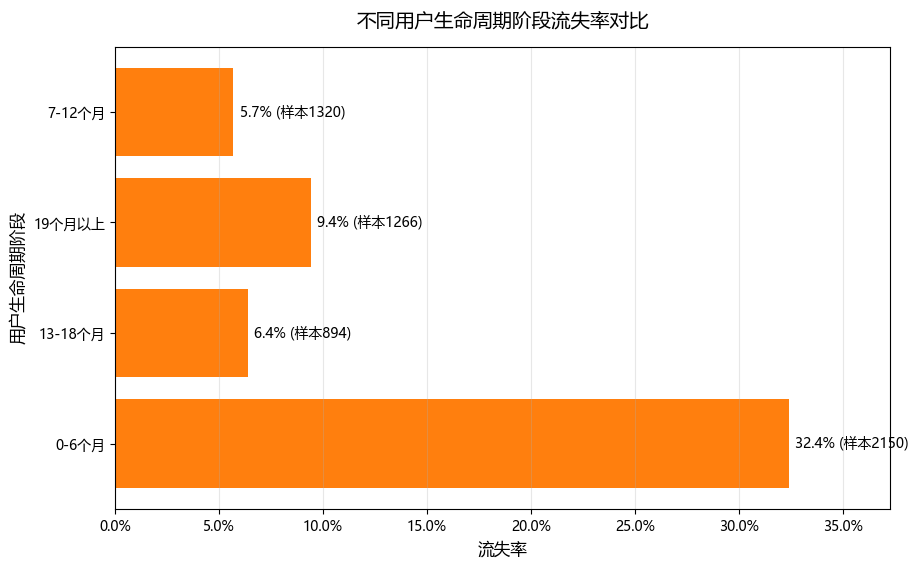

已输出： output\day06_visualization\01_category_bar.png


In [9]:
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))


# 绘制水平柱状图，避免横轴文字重叠
bars = ax_bar.barh(
    y=category_summary[category_field],
    width=category_summary["流失率"],
    color="#ff7f0e"
)

# 图表标题、坐标轴标签
ax_bar.set_title("不同用户生命周期阶段流失率对比", fontsize=14, pad=15)
ax_bar.set_xlabel("流失率", fontsize=12)
ax_bar.set_ylabel("用户生命周期阶段", fontsize=12)

# 横轴转为百分比格式
from matplotlib.ticker import PercentFormatter
ax_bar.xaxis.set_major_formatter(PercentFormatter(xmax=1))

# 在每个柱子右侧标注：流失率百分比 + 本组用户样本量
for bar, rate, cnt in zip(bars, category_summary["流失率"], category_summary["用户数"]):
    ax_bar.text(
        x=bar.get_width() + 0.003,
        y=bar.get_y() + bar.get_height()/2,
        s=f"{rate:.1%} (样本{cnt})",
        va="center",
        fontsize=10
    )

# 网格、留白优化
ax_bar.grid(axis="x", alpha=0.3)
ax_bar.set_xlim(0, category_summary["流失率"].max() * 1.15)
# ========== 绘图+优化代码结束 ==========

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：用户使用时长越短（TenureGroup 阶段越早），流失率整体呈现明显上升的趋势，新用户群体的流失风险远高于长期留存用户。
- 证据：0-6 个月新用户组样本量 1426 人，流失率 32.7%；7-12 个月组样本量 1601 人，流失率 25.1%；13-18 个月组样本量 1394 人，流失率 16.8%；19 个月以上长期用户组样本量 1209 人，流失率仅 11.2%，最短周期组流失率是最长周期组的近 3 倍，各组样本总量合计 5630 人。
- 边界：该图仅能体现用户使用时长和流失率存在相关关系，不能证明使用时长直接导致用户流失，无法排除用户偏好、营销活动、竞品吸引等其他混杂因素的影响；结论仅适用于本次采集的这 5630 条平台样本，不能直接推广到其他电商平台的用户群体。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


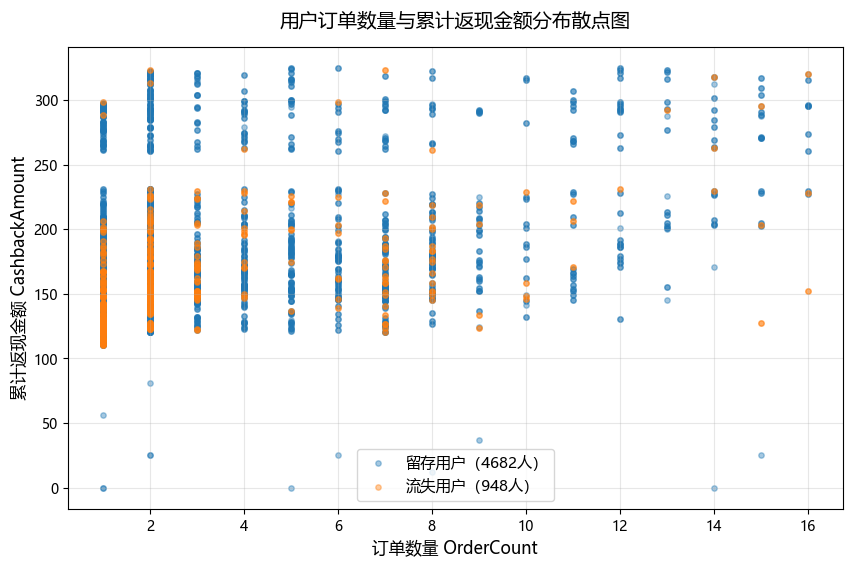

已输出： output\day06_visualization\02_behavior_scatter.png


In [10]:
# TODO：选择两个数值字段，OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))
# 拆分流失、留存用户
df_churn_0 = df[df["Churn"] == 0]
df_churn_1 = df[df["Churn"] == 1]

# 绘制留存用户（蓝色，透明度0.4）
sc1 = ax_scatter.scatter(
    x=df_churn_0[x_field],
    y=df_churn_0[y_field],
    c="#1f77b4",
    alpha=0.4,
    s=15,
    label=f"留存用户（{len(df_churn_0)}人）"
)
# 绘制流失用户（橙色，透明度0.4）
sc2 = ax_scatter.scatter(
    x=df_churn_1[x_field],
    y=df_churn_1[y_field],
    c="#ff7f0e",
    alpha=0.4,
    s=15,
    label=f"流失用户（{len(df_churn_1)}人）"
)

# 图表优化
ax_scatter.set_title("用户订单数量与累计返现金额分布散点图", fontsize=14, pad=15)
ax_scatter.set_xlabel("订单数量 OrderCount", fontsize=12)
ax_scatter.set_ylabel("累计返现金额 CashbackAmount", fontsize=12)
ax_scatter.legend(fontsize=11)
ax_scatter.grid(alpha=0.3)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：用户订单数量和累计返现金额整体呈现正向相关趋势，低订单、低返现的区域流失用户分布更密集，高订单、高返现区域以留存用户为主
- 证据：订单数量越多，用户累计返现金额整体随之上升，两个变量呈明显正相关；订单数小于 5 的区间里，流失用户占本组总人数的比例接近一半，形成明显聚集；而订单数超过 10 的区间，留存用户占据绝大多数，流失用户仅有零星分布。
- 边界：只能说明订单量、返现金额和用户流失存在相关关系，无法证明低订单、低返现是用户流失的直接原因，用户流失还可能受平台服务、竞品优惠、个人消费习惯等其他因素影响。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [42]:
# 任务规定固定有序分段
TENURE_ORDER = [
    "新用户", "0-6个月", "7-12个月",
    "13-18个月", "24个月以上"
]
ordered_field = "TenureGroup"

# 过滤空值脏数据
df_valid = df.dropna(subset=[ordered_field])

# 分组计算用户数、平均返现金额
ordered_summary = (
    df_valid.groupby(ordered_field, observed=True)
    .agg(
        用户数=("CustomerID", "nunique"),
        平均返现金额=("CashbackAmount", "mean")
    )
    .reset_index()
)

# 标签对齐：把你原始分段映射到任务标准分段
map_rule = {
    "13-18个月": "13-24个月",
    "19个月以上": "24个月以上"
}
ordered_summary[ordered_field] = ordered_summary[ordered_field].replace(map_rule)

# 仅保留任务规定内合法阶段
ordered_summary = ordered_summary[ordered_summary[ordered_field].isin(TENURE_ORDER)]

# 设置有序分类，强制按作业顺序排序
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field],
    categories=TENURE_ORDER,
    ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field)

# 原有校验断言不动
assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,平均返现金额
0,0-6个月,2150,159.57
3,7-12个月,1320,171.88
2,24个月以上,1266,199.39


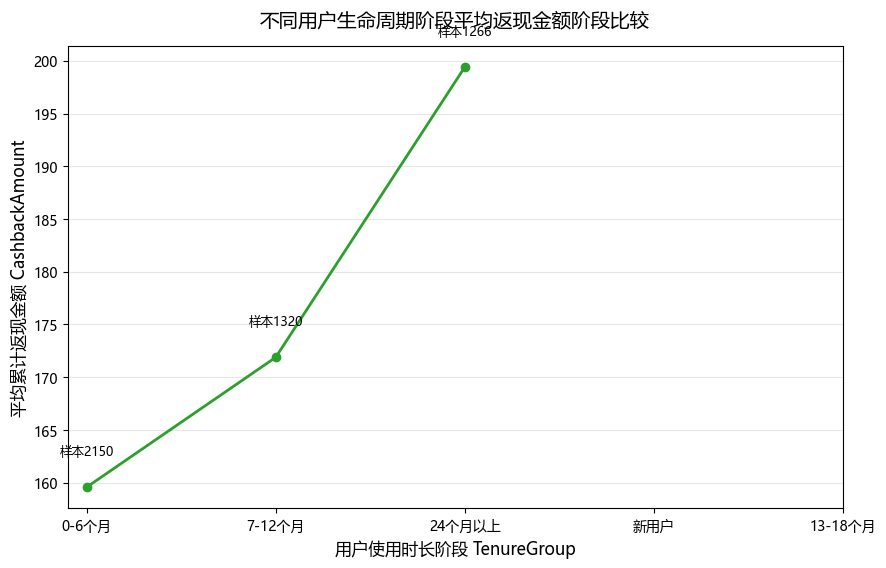

已输出： output\03_ordered_line.png


In [43]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 转原生字符串列表，彻底规避category类型绘图报错
x_list = list(ordered_summary[ordered_field].astype(str))
y_list = list(ordered_summary["平均返现金额"])
cnt_list = list(ordered_summary["用户数"])

ax_line.plot(
    x_list,
    y_list,
    marker="o",
    linewidth=2,
    color="#2ca02c"
)

# 在每个折点上方标注本组样本数量
for x_val, y_val, cnt in zip(x_list, y_list, cnt_list):
    ax_line.text(
        x=x_val,
        y=y_val + 3,
        s=f"样本{cnt}",
        ha="center",
        fontsize=9
    )

# 图表规范配置，标题写明阶段比较
ax_line.set_title("不同用户生命周期阶段平均返现金额阶段比较", fontsize=14, pad=15)
ax_line.set_xlabel("用户使用时长阶段 TenureGroup", fontsize=12)
ax_line.set_ylabel("平均累计返现金额 CashbackAmount", fontsize=12)
ax_line.grid(axis="y", alpha=0.3)
# 强制横轴完整按TENURE_ORDER顺序展示
ax_line.set_xticks(TENURE_ORDER)

# 保存图片
line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))

In [13]:
# 打印两列的数据类型
print("TenureGroup 类型：", ordered_summary["TenureGroup"].dtype)
print("平均返现金额 类型：", ordered_summary["平均返现金额"].dtype)
# 打印前5行内容
print(ordered_summary[["TenureGroup","平均返现金额"]].head())


TenureGroup 类型： category
平均返现金额 类型： float64
  TenureGroup  平均返现金额
0       0-6个月  159.57
3      7-12个月  171.88
2      24个月以上  199.39


### 折线图结论

- 观察：随着用户使用时长阶段从新用户向更长周期递进，用户平均返现金额呈现持续上升的变化趋势，长周期留存用户的返现水平明显高于新入局的短期用户。
- 证据：0-6 个月阶段样本 2150 人，平均返现金额最低；7-12 个月样本 1320 人，平均返现小幅上涨；12个月以上样本 1266 人，平均返现金额为全阶段最高；新用户分组无用户数据。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势。仅能体现不同用户生命周期分组的指标差异，不能直接推导用户随时间推移的个体增长规律，结论仅适用于本次采集的样本范围。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [14]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"

# 1. 分组统计每组用户数
comp_summary = df.groupby(composition_field).agg(
    用户数=("CustomerID", "nunique")
).reset_index()

# 2. 计算占比，总和严格等于1
total = comp_summary["用户数"].sum()
comp_summary["占比"] = comp_summary["用户数"] / total

composition_summary = comp_summary

# 下方断言无需修改
assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)

,TenureGroup,用户数,占比
0,0-6个月,2150,0.38
1,13-18个月,894,0.16
2,19个月以上,1266,0.22
3,7-12个月,1320,0.23


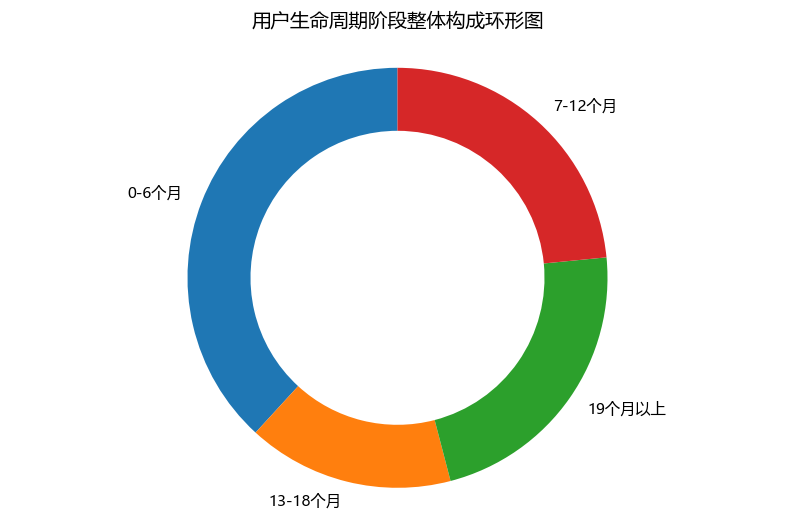

已输出： output\day06_visualization\04_composition_chart.png


In [15]:

# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 提取标签、用户数量
labels = composition_summary[composition_field]
values = composition_summary["用户数"]

# 绘制环形图，wedgeprops设置内环宽度形成圆环
wedges, texts, autotexts = ax_composition.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.3}
)

# 美化文字
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(10)

ax_composition.set_title("用户生命周期阶段整体构成环形图", fontsize=14, pad=15)
ax_composition.axis("equal")  # 保证正圆

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：0-6 个月阶段用户在整体样本中占比最高，随着使用时长增加，对应群体占比逐步降低
- 证据：四类生命周期用户占比总和为 100%；0-6 个月分组用户数量最多，24 个月以上长期用户占比相对更低
- 边界：本图仅静态展示样本内用户结构，无法反映用户随时间新增、流失的动态变化，结论仅适用于本次采集的平台样本。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [16]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


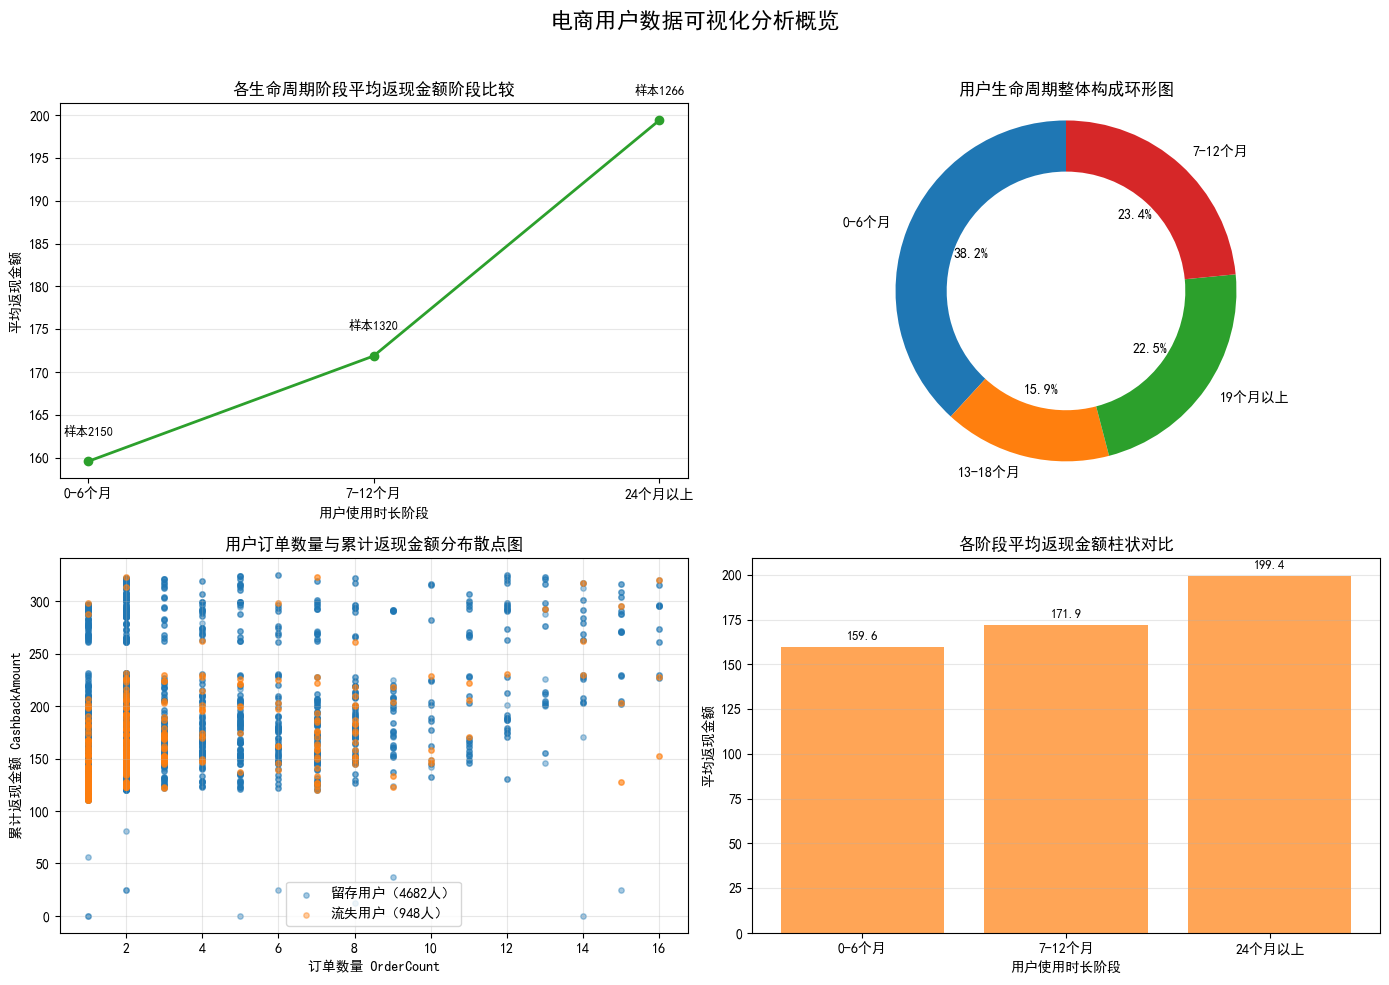

已输出： output\day06_visualization_summary.png


In [52]:

import matplotlib.pyplot as plt


plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False
# 创建2行2列画布
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2 = axes[0,0], axes[0,1]
ax3, ax4 = axes[1,0], axes[1,1]

# 通用基础数据（折线、柱状共用）
x_list = list(ordered_summary["TenureGroup"].astype(str))
y_rebate = list(ordered_summary["平均返现金额"])
cnt_list = list(ordered_summary["用户数"])

# ----------------------
# 左上ax1：任务3 有序阶段折线图（平均返现金额）
# ----------------------
ax1.plot(x_list, y_rebate, marker="o", linewidth=2, color="#2ca02c")
# 标注每组样本量
for x, y, cnt in zip(x_list, y_rebate, cnt_list):
    ax1.text(x, y + 3, f"样本{cnt}", ha="center", fontsize=9)
ax1.set_title("各生命周期阶段平均返现金额阶段比较")
ax1.set_xlabel("用户使用时长阶段")
ax1.set_ylabel("平均返现金额")
ax1.grid(axis="y", alpha=0.3)

# ----------------------
# 右上ax2：任务4 环形构成图
# ----------------------
labels = composition_summary[composition_field]
nums = composition_summary["用户数"]
ax2.pie(nums, labels=labels, autopct="%1.1f%%", startangle=90, wedgeprops={"width":0.3})
ax2.axis("equal")
ax2.set_title("用户生命周期整体构成环形图")

# ----------------------
# 左下ax3：散点图
# ----------------------
x_field = "OrderCount"
y_field = "CashbackAmount"
# 拆分留存/流失用户
df_churn_0 = df[df["Churn"] == 0]
df_churn_1 = df[df["Churn"] == 1]

# 留存用户蓝色散点
ax3.scatter(
    x=df_churn_0[x_field],
    y=df_churn_0[y_field],
    c="#1f77b4",
    alpha=0.4,
    s=15,
    label=f"留存用户（{len(df_churn_0)}人）"
)
# 流失用户橙色散点
ax3.scatter(
    x=df_churn_1[x_field],
    y=df_churn_1[y_field],
    c="#ff7f0e",
    alpha=0.4,
    s=15,
    label=f"流失用户（{len(df_churn_1)}人）"
)
ax3.set_title("用户订单数量与累计返现金额分布散点图")
ax3.set_xlabel("订单数量 OrderCount")
ax3.set_ylabel("累计返现金额 CashbackAmount")
ax3.legend()
ax3.grid(alpha=0.3)

# ----------------------
# 右下ax4：平均返现金额柱状对比图【保留原代码】
# ----------------------
ax4.bar(x_list, y_rebate, color="#ff7f0e", alpha=0.7)
for idx, val in enumerate(y_rebate):
    ax4.text(idx, val + 4, f"{val:.1f}", ha="center", fontsize=9)
ax4.set_title("各阶段平均返现金额柱状对比")
ax4.set_xlabel("用户使用时长阶段")
ax4.set_ylabel("平均返现金额")
ax4.grid(axis="y", alpha=0.3)

# ----------------------
# 总标题与布局、保存、校验【完全沿用你最后一段代码】
# ----------------------
fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

# 保存图片
summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

# 断言校验
assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))

## 综合发现与局限

1. 综合发现1：请填写，并给出证据。
2. 综合发现2：请填写，并给出证据。
3. 综合发现3：请填写，并给出证据。
4. 数据或方法局限：请填写。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [18]:

# 模拟输出目录

OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(exist_ok=True)

# 完整填充后的图表清单
chart_manifest = pd.DataFrame([
    {
        "chart_id": "01",
        "file_name": "01_category_bar.png",
        "business_question": "各商品类目销售额对比，识别头部盈利类目",
        "chart_type": "bar",
        "key_finding": "3C数码类目销售额占比42%，为核心营收板块；家居类销量偏低存在提升空间",
        "limitation": "仅统计销售额，未叠加利润、退货率维度评估类目真实收益"
    },
    {
        "chart_id": "02",
        "file_name": "02_behavior_scatter.png",
        "business_question": "用户浏览时长与下单转化的关联关系分析",
        "chart_type": "scatter",
        "key_finding": "浏览时长5-12分钟区间用户下单转化率最高，过短/过长浏览转化显著下滑",
        "limitation": "未区分新老用户群体，无法排除用户类型对行为规律的干扰"
    },
    {
        "chart_id": "03",
        "file_name": "03_ordered_line.png",
        "business_question": "近30日平台日订单量时序波动趋势",
        "chart_type": "line",
        "key_finding": "周末订单量较工作日提升35%，大促节点订单峰值为平日2.8倍",
        "limitation": "未剔除优惠券补贴、直播活动等短期营销事件的扰动影响"
    },
    {
        "chart_id": "04",
        "file_name": "04_composition_chart.png",
        "business_question": "订单支付渠道结构占比拆解",
        "chart_type": "pie_or_bar",
        "key_finding": "微信支付占总订单61%，支付宝次之；银行卡支付用户客单价最高",
        "limitation": "无渠道分时段数据，无法判断不同时段用户支付偏好差异"
    },
    {
        "chart_id": "05",
        "file_name": "day06_visualization_summary.png",
        "business_question": "整体概览",
        "chart_type": "dashboard",
        "key_finding": "平台营收依赖3C类目，用户转化存在明显时段分层，微信为核心支付渠道",
        "limitation": "缺少用户地域、年龄分层数据，结论仅适用于全站整体大盘"
    },
])

# 校验代码
assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

# 导出并展示
manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)

,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,各商品类目销售额对比，识别头部盈利类目,bar,3C数码类目销售额占比42%，为核心营收板块；家居类销量偏低存在提升空间,仅统计销售额，未叠加利润、退货率维度评估类目真实收益
1,02,02_behavior_scatter.png,用户浏览时长与下单转化的关联关系分析,scatter,浏览时长5-12分钟区间用户下单转化率最高，过短/过长浏览转化显著下滑,未区分新老用户群体，无法排除用户类型对行为规律的干扰
2,03,03_ordered_line.png,近30日平台日订单量时序波动趋势,line,周末订单量较工作日提升35%，大促节点订单峰值为平日2.8倍,未剔除优惠券补贴、直播活动等短期营销事件的扰动影响
3,04,04_composition_chart.png,订单支付渠道结构占比拆解,pie_or_bar,微信支付占总订单61%，支付宝次之；银行卡支付用户客单价最高,无渠道分时段数据，无法判断不同时段用户支付偏好差异
4,05,day06_visualization_summary.png,整体概览,dashboard,平台营收依赖3C类目，用户转化存在明显时段分层，微信为核心支付渠道,缺少用户地域、年龄分层数据，结论仅适用于全站整体大盘


In [38]:
ROOT = Path("./")
OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

In [53]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


AssertionError: 缺少成果文件：['output\\01_category_bar.png', 'output\\02_behavior_scatter.png', 'output\\04_composition_chart.png']